# DELight full-model inference

This notebook loads an inference checkpoint together with its neighboring `run_config.json`, reconstructs the exact model architecture, reads real events from an H5 shard, and runs normal and channel-masked inference.

The active full run saves a checkpoint every 5,000 optimizer steps. Until the first full-run checkpoint exists, automatic discovery falls back to the completed full-dataset pilot.

In [1]:
from __future__ import annotations

import json
import re
import sys
from contextlib import nullcontext
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "reconstruction_model").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the transformer repository.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from reconstruction_model.checkpoints import load_checkpoint
from reconstruction_model.models import create_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repository:", REPO_ROOT)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Repository: /ceph/dwong/transformer
Device: cuda
GPU: NVIDIA L40S


## Select a checkpoint

Leave `RUN_DIRECTORY = None` for automatic discovery. To select a specific run, set it to a checkpoint directory such as:

```python
RUN_DIRECTORY = REPO_ROOT / "artifacts/pairwise_full_local_l40s/checkpoints/20260623_134638"
```

Only fully written `reconstruction_model_<STEP>.pt` files are considered.

In [2]:
RUN_DIRECTORY = None
CHECKPOINT_STEP = None  # Set an integer to load a specific step.


def checkpoint_step(path: Path) -> int:
    match = re.fullmatch(r"reconstruction_model_(\d+)\.pt", path.name)
    return int(match.group(1)) if match else -1


def discover_run_directory() -> Path:
    search_roots = [
        REPO_ROOT / "artifacts/pairwise_full_local_l40s/checkpoints",
        REPO_ROOT / "artifacts/pairwise_full_pilot_local_l40s/checkpoints",
        REPO_ROOT / "artifacts/pairwise_compact_local_l40s/checkpoints",
    ]
    candidates = []
    for search_root in search_roots:
        if not search_root.exists():
            continue
        for run_dir in search_root.iterdir():
            checkpoints = list(run_dir.glob("reconstruction_model_*.pt"))
            if checkpoints and (run_dir / "run_config.json").exists():
                candidates.append((run_dir.stat().st_mtime, run_dir))
        if candidates:
            # Prefer a usable full run over pilot/compact runs.
            return max(candidates)[1]
    raise FileNotFoundError("No completed model checkpoint was found.")


run_dir = Path(RUN_DIRECTORY) if RUN_DIRECTORY is not None else discover_run_directory()
if CHECKPOINT_STEP is None:
    checkpoint_path = max(run_dir.glob("reconstruction_model_*.pt"), key=checkpoint_step)
else:
    checkpoint_path = run_dir / f"reconstruction_model_{CHECKPOINT_STEP}.pt"
config_path = run_dir / "run_config.json"

if not checkpoint_path.exists() or not config_path.exists():
    raise FileNotFoundError((checkpoint_path, config_path))

print("Run directory:", run_dir)
print("Checkpoint:", checkpoint_path.name)
print("Step:", checkpoint_step(checkpoint_path))

Run directory: /ceph/dwong/transformer/artifacts/pairwise_full_local_l40s/checkpoints/20260623_134638
Checkpoint: reconstruction_model_150000.pt
Step: 150000


## Reconstruct and load the model

The model-only checkpoint is the correct file for inference. The larger `reconstruction_resume_*.pt` files additionally contain optimizer and scheduler state and are intended for resuming training.

In [3]:
run_config = json.loads(config_path.read_text())
variant = run_config["model_variant"]
model_overrides = dict(run_config["model_config"])

# Use the package-local geometry cache on the current machine rather than a
# path recorded on the training host.
model_overrides.pop("pairwise_feats_path", None)

model, model_config = create_model(variant, **model_overrides)
load_checkpoint(model, checkpoint_path, str(DEVICE))
model.to(DEVICE)
model.eval()

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Variant:", variant)
print("Parameters:", f"{parameter_count:,}")
print("Configuration:", model_config)
print("Checkpoint loaded successfully.")

Variant: pairwise_channel_masking
Parameters: 6,817,688
Configuration: TransformerConfig(max_seq_len=65536, patch_len=128, patch_stride=128, d_model=128, d_ff=512, n_channel_blocks=4, n_temporal_blocks=4, n_head=4, dropout_transformer=0.15, d_hidden_bias_ffn=64, dropout_ffn=0.15, rope_base=10000.0, n_channels=56, norm_eps=1e-06, n_edge_feats=4, pairwise_feats_path=PosixPath('/ceph/dwong/transformer/reconstruction_model/models/cache/edge_feats.npy'), top_channel_indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55], mask_channel_prob=0.1)
Checkpoint loaded successfully.


## Load real events

Change `H5_PATH` and `SAMPLE_INDICES` as needed. The expected waveform shape is `(events, 56, 65536)`.

In [4]:
H5_PATH = Path("/ceph/srv/dwong/training_samples_h5/ER/ER_traces_energy_100_batch_0000.h5")
SAMPLE_INDICES = [0, 1, 2, 3]


def decode_recoil(value) -> str:
    if isinstance(value, bytes):
        return value.decode("utf-8")
    if hasattr(value, "decode"):
        return value.decode("utf-8")
    return str(value)


with h5py.File(H5_PATH, "r") as handle:
    traces = handle["traces"][SAMPLE_INDICES].astype(np.float32)
    events = handle["events"][SAMPLE_INDICES]

inputs = torch.from_numpy(traces)
truth = pd.DataFrame({
    "event_index": SAMPLE_INDICES,
    "true_x": events["x"].astype(float),
    "true_y": events["y"].astype(float),
    "true_z": events["z"].astype(float),
    "true_energy": events["energy"].astype(float),
    "true_recoil": [decode_recoil(value) for value in events["type_recoil"]],
})

print("H5:", H5_PATH)
print("Input shape:", tuple(inputs.shape))
display(truth)

H5: /ceph/srv/dwong/training_samples_h5/ER/ER_traces_energy_100_batch_0000.h5
Input shape: (4, 56, 65536)


,event_index,true_x,true_y,true_z,true_energy,true_recoil
0,0,-24.005014,85.868095,-1689.876777,100.0,ER
1,1,-65.014113,3.712705,-1702.631975,100.0,ER
2,2,-40.238144,84.394804,-1698.717852,100.0,ER
3,3,-44.968828,16.982450,-1702.374538,100.0,ER


## Run inference

The outputs are `(x, y)`, energy, and an NR classification logit. `NR probability >= 0.5` is classified as NR. Inference uses BF16 autocast on CUDA and FP32 on CPU.

In [5]:
@torch.inference_mode()
def predict(batch: torch.Tensor, mask_mode: str | None = None):
    # The channel-masking model applies its mask in place, so clone the
    # input to keep repeated normal/masked predictions independent.
    batch = batch.to(DEVICE, dtype=torch.float32).clone()
    channel_mask = None
    if mask_mode is not None:
        channel_mask = model.get_inference_mask(mask_mode).expand(batch.size(0), -1, -1)

    autocast_context = (
        torch.autocast(device_type="cuda", dtype=torch.bfloat16)
        if DEVICE.type == "cuda"
        else nullcontext()
    )
    with autocast_context:
        spatial, energy, class_logits = model(batch, channel_mask=channel_mask)

    nr_probability = torch.sigmoid(class_logits.float())
    return (
        spatial.float().cpu().numpy(),
        energy.float().cpu().numpy().reshape(-1),
        nr_probability.cpu().numpy().reshape(-1),
    )


spatial_pred, energy_pred, nr_probability = predict(inputs)
results = truth.copy()
results["pred_x"] = spatial_pred[:, 0]
results["pred_y"] = spatial_pred[:, 1]
results["pred_energy"] = energy_pred
results["pred_nr_probability"] = nr_probability
results["pred_recoil"] = np.where(nr_probability >= 0.5, "NR", "ER")
results["xy_error"] = np.sqrt(
    (results["pred_x"] - results["true_x"]) ** 2
    + (results["pred_y"] - results["true_y"]) ** 2
)
results["energy_error"] = results["pred_energy"] - results["true_energy"]
display(results.round(4))

,event_index,true_x,true_y,true_z,true_energy,true_recoil,pred_x,pred_y,pred_energy,pred_nr_probability,pred_recoil,xy_error,energy_error
0,0,-24.0050,85.8681,-1689.8768,100.0,ER,-25.25,80.0000,93.5,0.0005,ER,5.9987,-6.5
1,1,-65.0141,3.7127,-1702.6320,100.0,ER,-65.00,7.6562,95.5,0.0001,ER,3.9436,-4.5
2,2,-40.2381,84.3948,-1698.7179,100.0,ER,-47.25,87.5000,95.5,0.0000,ER,7.6687,-4.5
3,3,-44.9688,16.9824,-1702.3745,100.0,ER,-47.50,16.3750,97.5,0.0015,ER,2.6030,-2.5


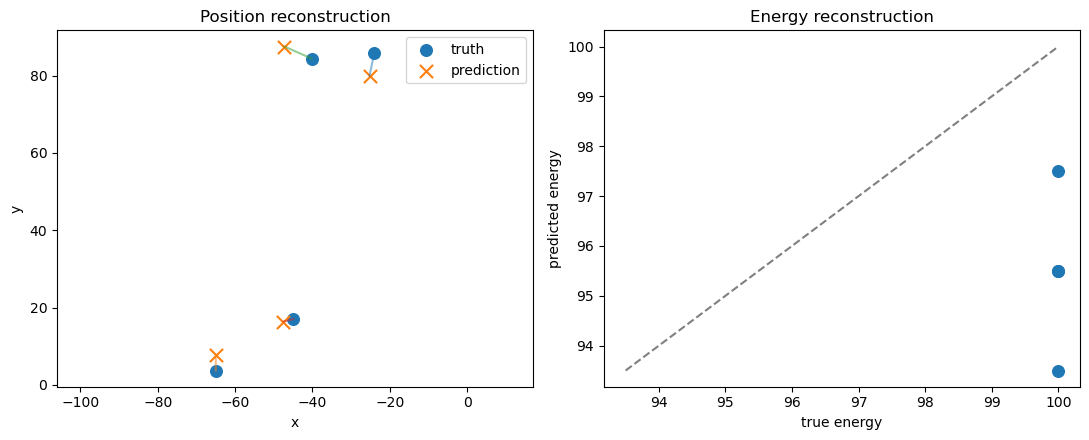

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(results["true_x"], results["true_y"], label="truth", s=70)
axes[0].scatter(results["pred_x"], results["pred_y"], label="prediction", marker="x", s=90)
for row in results.itertuples():
    axes[0].plot([row.true_x, row.pred_x], [row.true_y, row.pred_y], alpha=0.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Position reconstruction")
axes[0].legend()
axes[0].axis("equal")

axes[1].scatter(results["true_energy"], results["pred_energy"], s=70)
limits = [
    min(results["true_energy"].min(), results["pred_energy"].min()),
    max(results["true_energy"].max(), results["pred_energy"].max()),
]
axes[1].plot(limits, limits, "--", color="gray")
axes[1].set_xlabel("true energy")
axes[1].set_ylabel("predicted energy")
axes[1].set_title("Energy reconstruction")

plt.tight_layout()
plt.show()

## Optional channel-masking study

`top_mask` removes the configured top detector channels; `bot_mask` removes the bottom channels. This is useful for testing the robustness learned by `pairwise_channel_masking`.

In [7]:
mask_results = []
for mask_mode in (None, "top_mask", "bot_mask"):
    spatial, energy, nr_prob = predict(inputs, mask_mode=mask_mode)
    for row_index, event_index in enumerate(SAMPLE_INDICES):
        mask_results.append({
            "event_index": event_index,
            "mask": mask_mode or "none",
            "pred_x": spatial[row_index, 0],
            "pred_y": spatial[row_index, 1],
            "pred_energy": energy[row_index],
            "pred_nr_probability": nr_prob[row_index],
        })

mask_results = pd.DataFrame(mask_results)
display(mask_results.round(4))

,event_index,mask,pred_x,pred_y,pred_energy,pred_nr_probability
0,0,none,-25.2500,80.0000,93.5,0.0005
1,1,none,-65.0000,7.6562,95.5,0.0001
2,2,none,-47.2500,87.5000,95.5,0.0000
3,3,none,-47.5000,16.3750,97.5,0.0015
4,0,top_mask,-5.7812,67.5000,124.5,0.0851
5,1,top_mask,-52.5000,16.3750,117.0,0.0792
6,2,top_mask,-56.0000,91.0000,126.5,0.2268
7,3,top_mask,-50.2500,26.7500,172.0,0.2854
8,0,bot_mask,-27.0000,85.5000,68.0,0.6584
9,1,bot_mask,-65.5000,8.0000,75.5,0.0056


## Batch inference pattern

For a large file, iterate over slices rather than loading every waveform into RAM at once:

In [8]:
def infer_h5_file(path: Path, batch_size: int = 8, max_events: int | None = None) -> pd.DataFrame:
    rows = []
    with h5py.File(path, "r") as handle:
        total = len(handle["events"])
        if max_events is not None:
            total = min(total, max_events)
        for start in range(0, total, batch_size):
            stop = min(start + batch_size, total)
            batch = torch.from_numpy(handle["traces"][start:stop].astype(np.float32))
            metadata = handle["events"][start:stop]
            spatial, energy, nr_prob = predict(batch)
            for offset in range(stop - start):
                rows.append({
                    "event_index": start + offset,
                    "true_x": float(metadata[offset]["x"]),
                    "true_y": float(metadata[offset]["y"]),
                    "true_energy": float(metadata[offset]["energy"]),
                    "true_recoil": decode_recoil(metadata[offset]["type_recoil"]),
                    "pred_x": float(spatial[offset, 0]),
                    "pred_y": float(spatial[offset, 1]),
                    "pred_energy": float(energy[offset]),
                    "pred_nr_probability": float(nr_prob[offset]),
                })
    return pd.DataFrame(rows)


# Example: infer only the first 16 events.
file_results = infer_h5_file(H5_PATH, batch_size=4, max_events=16)
display(file_results.head())

,event_index,true_x,true_y,true_energy,true_recoil,pred_x,pred_y,pred_energy,pred_nr_probability
0,0,-24.005014,85.868095,100.0,ER,-25.25,80.00000,93.5,0.000458
1,1,-65.014113,3.712705,100.0,ER,-65.00,7.65625,95.5,0.000123
2,2,-40.238144,84.394804,100.0,ER,-47.25,87.50000,95.5,0.000033
3,3,-44.968828,16.982450,100.0,ER,-47.50,16.37500,97.5,0.001501
4,4,30.577650,67.451938,100.0,ER,33.50,67.00000,98.5,0.014957


## Balanced 600-event reconstruction check

This section samples 100 events per energy, split evenly across ER and NR, runs normal full-channel inference, and plots energy/position reconstruction. It intentionally does **not** use `top_mask` or `bot_mask`.

For the position view, dense truth/prediction overlays become hard to read, so the plots below use an error map, a light residual-vector overlay, x/y diagonal checks, and an XY-error histogram.

In [9]:
EVENTS_PER_ENERGY = 100
BALANCED_SAMPLE_SEED = 123
DATASET_ROOT = Path("/ceph/srv/dwong/training_samples_h5")
EVALUATION_RECOILS = ["ER", "NR"]
EVALUATION_ENERGIES = [10, 20, 50, 100, 200, 500]
SAMPLE_TOTAL = EVENTS_PER_ENERGY * len(EVALUATION_ENERGIES)


def make_energy_balanced_sample_plan(
    dataset_root: Path,
    events_per_energy: int = 100,
    energies: list[int] | None = None,
    recoils: list[str] | None = None,
    seed: int = 123,
) -> list[dict]:
    """Sample the same number of events per energy, balanced over recoil types."""
    energies = energies or EVALUATION_ENERGIES
    recoils = recoils or EVALUATION_RECOILS
    rng = np.random.default_rng(seed)
    plan = []

    for energy in energies:
        base_count = events_per_energy // len(recoils)
        remainder = events_per_energy % len(recoils)
        for recoil_index, recoil in enumerate(recoils):
            group_count = base_count + (1 if recoil_index < remainder else 0)
            files = sorted((dataset_root / recoil).glob(f"{recoil}_traces_energy_{energy}_batch_*.h5"))
            if not files:
                raise FileNotFoundError(f"No H5 files for {recoil} {energy} keV under {dataset_root}")

            for _ in range(group_count):
                path = files[int(rng.integers(0, len(files)))]
                with h5py.File(path, "r") as handle:
                    event_idx = int(rng.integers(0, len(handle["events"])))
                plan.append({
                    "path": path,
                    "event_idx": event_idx,
                    "requested_recoil": recoil,
                    "requested_energy": energy,
                })

    rng.shuffle(plan)
    return plan


# Backward-compatible alias if you reused the older notebook cell name elsewhere.
def make_balanced_sample_plan(
    dataset_root: Path,
    total_events: int = 200,
    energies: list[int] | None = None,
    recoils: list[str] | None = None,
    seed: int = 123,
) -> list[dict]:
    energies = energies or EVALUATION_ENERGIES
    events_per_energy = max(1, total_events // len(energies))
    return make_energy_balanced_sample_plan(
        dataset_root,
        events_per_energy=events_per_energy,
        energies=energies,
        recoils=recoils,
        seed=seed,
    )


def infer_sample_plan(sample_plan: list[dict], batch_size: int = 8) -> pd.DataFrame:
    rows = []
    for start in range(0, len(sample_plan), batch_size):
        chunk = sample_plan[start:start + batch_size]
        traces = []
        metadata_rows = []

        for item in chunk:
            with h5py.File(item["path"], "r") as handle:
                traces.append(handle["traces"][item["event_idx"]].astype(np.float32))
                metadata_rows.append(handle["events"][item["event_idx"]])

        batch = torch.from_numpy(np.stack(traces, axis=0))
        spatial, energy, nr_prob = predict(batch)

        for offset, (item, metadata) in enumerate(zip(chunk, metadata_rows)):
            rows.append({
                "sample_index": start + offset,
                "source_file": item["path"].name,
                "event_index": item["event_idx"],
                "true_x": float(metadata["x"]),
                "true_y": float(metadata["y"]),
                "true_z": float(metadata["z"]),
                "true_energy": float(metadata["energy"]),
                "true_recoil": decode_recoil(metadata["type_recoil"]),
                "pred_x": float(spatial[offset, 0]),
                "pred_y": float(spatial[offset, 1]),
                "pred_energy": float(energy[offset]),
                "pred_nr_probability": float(nr_prob[offset]),
            })

    result = pd.DataFrame(rows)
    result["energy_error"] = result["pred_energy"] - result["true_energy"]
    result["abs_energy_error"] = result["energy_error"].abs()
    result["dx"] = result["pred_x"] - result["true_x"]
    result["dy"] = result["pred_y"] - result["true_y"]
    result["xy_error"] = np.sqrt(result["dx"] ** 2 + result["dy"] ** 2)
    result["pred_recoil"] = np.where(result["pred_nr_probability"] >= 0.5, "NR", "ER")
    result["class_correct"] = result["pred_recoil"] == result["true_recoil"]
    return result


sample_plan = make_energy_balanced_sample_plan(
    DATASET_ROOT,
    events_per_energy=EVENTS_PER_ENERGY,
    energies=EVALUATION_ENERGIES,
    recoils=EVALUATION_RECOILS,
    seed=BALANCED_SAMPLE_SEED,
)
balanced_results = infer_sample_plan(sample_plan, batch_size=8)

summary = (
    balanced_results
    .groupby(["true_recoil", "true_energy"])
    .agg(
        n=("sample_index", "size"),
        energy_bias=("energy_error", "mean"),
        energy_mae=("abs_energy_error", "mean"),
        energy_rmse=("energy_error", lambda values: np.sqrt(np.mean(np.square(values)))),
        dx_bias=("dx", "mean"),
        dy_bias=("dy", "mean"),
        xy_mean_error=("xy_error", "mean"),
        xy_rmse=("xy_error", lambda values: np.sqrt(np.mean(np.square(values)))),
        class_accuracy=("class_correct", "mean"),
    )
    .reset_index()
)

overall = pd.Series({
    "n": len(balanced_results),
    "events_per_energy": EVENTS_PER_ENERGY,
    "energy_bias": balanced_results["energy_error"].mean(),
    "energy_mae": balanced_results["abs_energy_error"].mean(),
    "energy_rmse": np.sqrt(np.mean(np.square(balanced_results["energy_error"]))),
    "dx_bias": balanced_results["dx"].mean(),
    "dy_bias": balanced_results["dy"].mean(),
    "xy_mean_error": balanced_results["xy_error"].mean(),
    "xy_rmse": np.sqrt(np.mean(np.square(balanced_results["xy_error"]))),
    "class_accuracy": balanced_results["class_correct"].mean(),
})

print(f"Sampled {len(balanced_results)} events: {EVENTS_PER_ENERGY} per energy, split across {EVALUATION_RECOILS}.")
print("Overall metrics")
display(overall.to_frame("value").T.round(4))
display(summary.round(4))
display(balanced_results.head().round(4))

Sampled 600 events: 100 per energy, split across ['ER', 'NR'].
Overall metrics


,n,events_per_energy,energy_bias,energy_mae,energy_rmse,dx_bias,dy_bias,xy_mean_error,xy_rmse,class_accuracy
value,600.0,100.0,2.1154,5.7896,10.8341,0.2327,-0.0784,5.1698,6.6012,0.8283


,true_recoil,true_energy,n,energy_bias,energy_mae,energy_rmse,dx_bias,dy_bias,xy_mean_error,xy_rmse,class_accuracy
0,ER,10.0,50,0.4200,0.7475,1.4687,1.7226,-0.2005,6.9919,8.1119,0.06
1,ER,20.0,50,-0.3975,1.2075,1.5130,0.7922,-1.5412,7.8362,11.9140,0.24
2,ER,50.0,50,3.2338,8.3762,12.9915,1.1233,0.4618,5.3690,6.3363,0.94
3,ER,100.0,50,-1.1900,8.5700,14.4314,-1.4251,0.7877,5.5944,6.4189,0.98
4,ER,200.0,50,-5.0700,5.9500,18.4115,1.1320,-0.6490,5.2430,6.0636,1.00
5,ER,500.0,50,17.4400,17.4400,17.5636,0.3217,0.3369,4.9194,5.4927,0.98
6,NR,10.0,50,0.0225,0.6050,0.9879,0.3583,-0.5241,7.5495,8.6412,0.86
7,NR,20.0,50,-0.6538,1.2588,1.7054,-0.1288,0.2301,3.7774,4.5384,0.98
8,NR,50.0,50,-1.4000,2.1600,2.7536,-0.2640,-0.0606,4.4534,4.9448,1.00
9,NR,100.0,50,-3.4400,3.7000,6.4823,-0.1242,0.5211,3.0514,3.6985,0.98


,sample_index,source_file,event_index,true_x,true_y,true_z,true_energy,true_recoil,pred_x,pred_y,pred_energy,pred_nr_probability,energy_error,abs_energy_error,dx,dy,xy_error,pred_recoil,class_correct
0,0,NR_traces_energy_50_batch_0014.h5,76,80.1588,-43.2373,-1692.2083,50.0,NR,76.5000,-36.0,50.25,0.8758,0.25,0.25,-3.6588,7.2373,8.1095,NR,True
1,1,ER_traces_energy_50_batch_0172.h5,31,-74.7867,41.8270,-1693.6126,50.0,ER,-72.5000,42.5,60.50,0.0028,10.50,10.50,2.2867,0.6730,2.3837,ER,True
2,2,ER_traces_energy_50_batch_0025.h5,26,93.2362,26.5709,-1696.4711,50.0,ER,95.0000,28.5,81.00,0.0006,31.00,31.00,1.7638,1.9291,2.6139,ER,True
3,3,NR_traces_energy_50_batch_0026.h5,12,-6.8350,-118.4382,-1706.7985,50.0,NR,-2.5938,-123.0,47.00,1.0000,-3.00,3.00,4.2412,-4.5618,6.2288,NR,True
4,4,ER_traces_energy_50_batch_0111.h5,68,-22.0075,-84.4156,-1700.3631,50.0,ER,-17.3750,-88.5,53.50,0.0005,3.50,3.50,4.6325,-4.0844,6.1760,ER,True


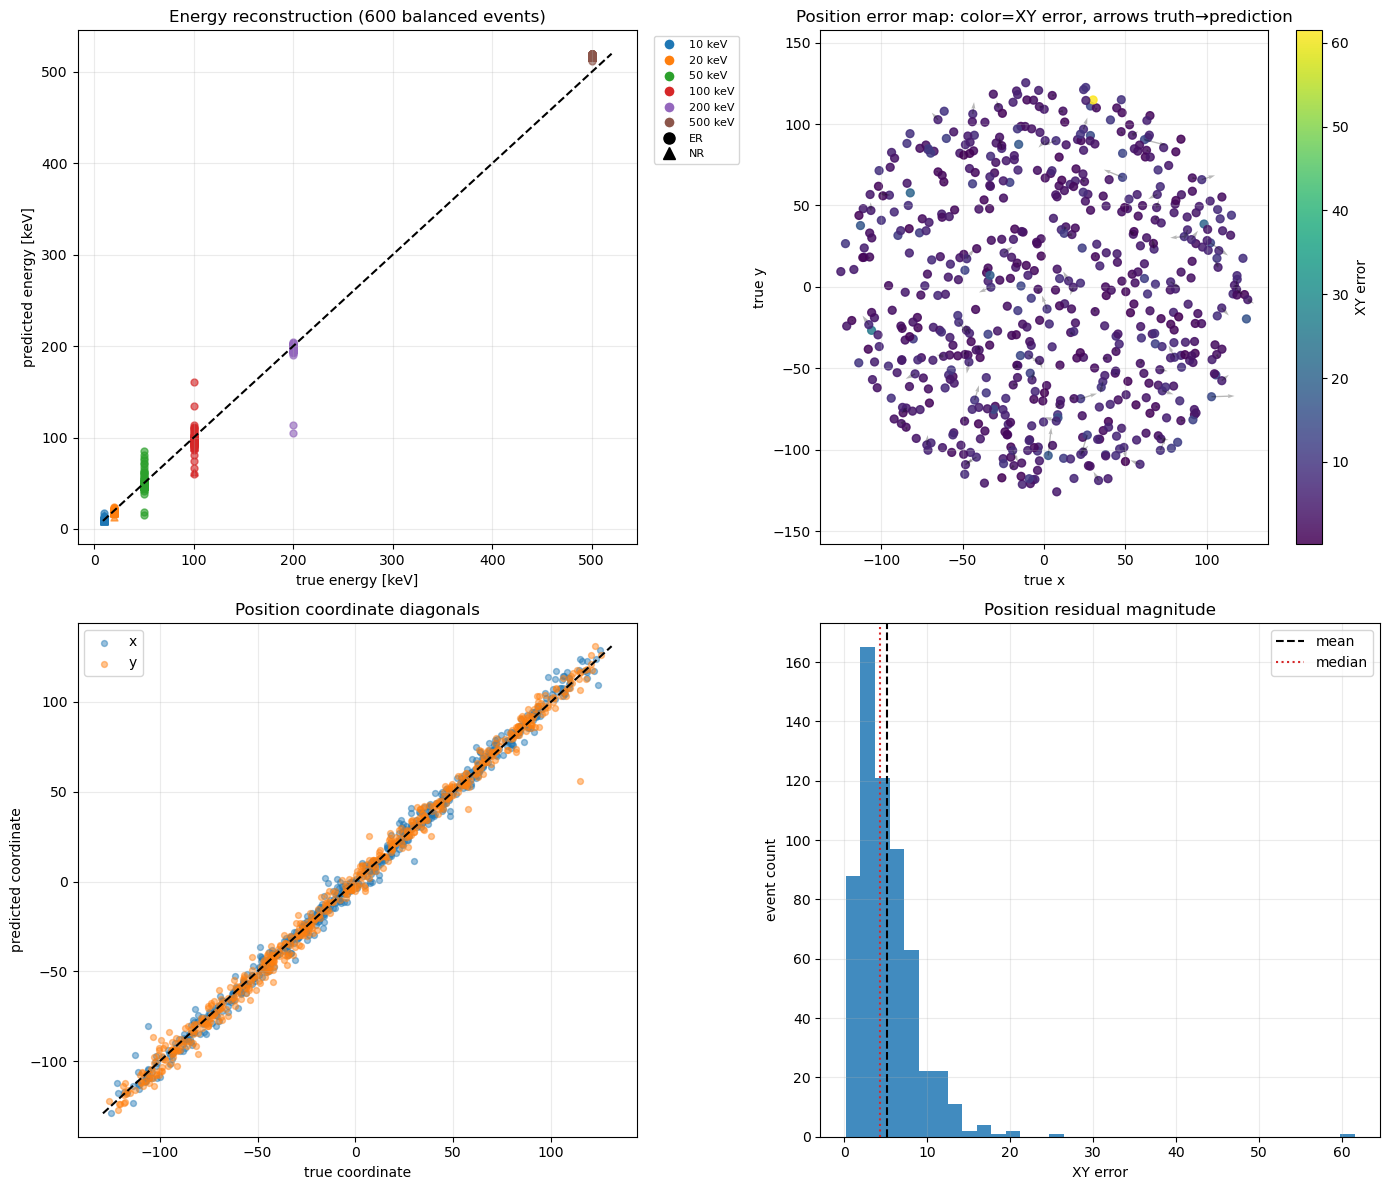

In [10]:
from matplotlib.lines import Line2D

energy_colors = {
    10: "tab:blue",
    20: "tab:orange",
    50: "tab:green",
    100: "tab:red",
    200: "tab:purple",
    500: "tab:brown",
}
recoil_markers = {"ER": "o", "NR": "^"}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
energy_ax, map_ax, diagonal_ax, hist_ax = axes.ravel()

# 1) Energy reconstruction diagonal.
for recoil, marker in recoil_markers.items():
    for true_energy, color in energy_colors.items():
        subset = balanced_results[
            (balanced_results["true_recoil"] == recoil)
            & (balanced_results["true_energy"] == true_energy)
        ]
        if subset.empty:
            continue
        energy_ax.scatter(
            subset["true_energy"],
            subset["pred_energy"],
            color=color,
            marker=marker,
            alpha=0.65,
            s=25,
        )

energy_min = min(balanced_results["true_energy"].min(), balanced_results["pred_energy"].min())
energy_max = max(balanced_results["true_energy"].max(), balanced_results["pred_energy"].max())
energy_ax.plot([energy_min, energy_max], [energy_min, energy_max], "--", color="black", linewidth=1.5)
energy_ax.set_xlabel("true energy [keV]")
energy_ax.set_ylabel("predicted energy [keV]")
energy_ax.set_title(f"Energy reconstruction ({len(balanced_results)} balanced events)")
energy_ax.grid(alpha=0.25)

# 2) Position error map in the detector plane.
point_plot = map_ax.scatter(
    balanced_results["true_x"],
    balanced_results["true_y"],
    c=balanced_results["xy_error"],
    cmap="viridis",
    s=32,
    alpha=0.85,
)
fig.colorbar(point_plot, ax=map_ax, label="XY error")

# Draw a readable subset of residual arrows; all 600 arrows would become spaghetti.
max_arrows = 120
arrow_step = max(1, len(balanced_results) // max_arrows)
arrow_subset = balanced_results.iloc[::arrow_step]
map_ax.quiver(
    arrow_subset["true_x"],
    arrow_subset["true_y"],
    arrow_subset["dx"],
    arrow_subset["dy"],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="black",
    alpha=0.28,
    width=0.003,
)
map_ax.set_xlabel("true x")
map_ax.set_ylabel("true y")
map_ax.set_title("Position error map: color=XY error, arrows truth→prediction")
map_ax.axis("equal")
map_ax.grid(alpha=0.25)

# 3) Coordinate-wise diagonal checks. This is less pretty, but more diagnostic
# than overlaying predicted and true positions in the detector plane.
coord_min = float(balanced_results[["true_x", "true_y", "pred_x", "pred_y"]].min().min())
coord_max = float(balanced_results[["true_x", "true_y", "pred_x", "pred_y"]].max().max())
diagonal_ax.scatter(balanced_results["true_x"], balanced_results["pred_x"], s=18, alpha=0.45, label="x")
diagonal_ax.scatter(balanced_results["true_y"], balanced_results["pred_y"], s=18, alpha=0.45, label="y")
diagonal_ax.plot([coord_min, coord_max], [coord_min, coord_max], "--", color="black", linewidth=1.5)
diagonal_ax.set_xlabel("true coordinate")
diagonal_ax.set_ylabel("predicted coordinate")
diagonal_ax.set_title("Position coordinate diagonals")
diagonal_ax.legend()
diagonal_ax.grid(alpha=0.25)

# 4) Residual magnitude distribution.
hist_ax.hist(balanced_results["xy_error"], bins=35, alpha=0.85, color="tab:blue")
hist_ax.axvline(balanced_results["xy_error"].mean(), color="black", linestyle="--", label="mean")
hist_ax.axvline(balanced_results["xy_error"].median(), color="tab:red", linestyle=":", label="median")
hist_ax.set_xlabel("XY error")
hist_ax.set_ylabel("event count")
hist_ax.set_title("Position residual magnitude")
hist_ax.legend()
hist_ax.grid(alpha=0.25)

energy_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color, label=f"{energy:g} keV", markersize=8)
    for energy, color in energy_colors.items()
]
recoil_handles = [
    Line2D([0], [0], marker=marker, color="black", linestyle="None", label=recoil, markersize=8)
    for recoil, marker in recoil_markers.items()
]
energy_ax.legend(handles=energy_handles + recoil_handles, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()